In [2]:
from data_processing import DataSetup, FigureFormat, ContinentalRegions

flight_matrix_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/country_flow_202001 1.csv'
country_codes_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/geom_countries_codes.csv'
population_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/WPP2019_TotalPopulation2020.csv'

flight_matrix, normalized_flow_matrix, source_countries, target_countries, source_codes, target_codes, population, name_mapping = DataSetup(flight_matrix_path, population_path, country_codes_path).load_and_process_data().values()
FigureFormat().set_figure_format()
continental_regions = ContinentalRegions().define_continental_regions()

/Users/reddy/AWW_and_ICU/wastewater_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-12 22:47:03,943	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import Rbf
import ast
import re
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [4]:
# Create country to region mapping
country_to_region = {}
for region_name, region_countries in continental_regions.items():
    for country in region_countries:
        country_to_region[country] = region_name
        
continent_colors = {
    'Africa': '#E74C3C',
    'Asia': '#3498DB',
    'Europe': '#2ECC71',
    'North and\nCentral America': '#F39C12',
    'South\nAmerica': '#9B59B6',
    'Oceania': '#1ABC9C'
}

region_order = ['Africa', 'Asia', 'Europe', 'North and\nCentral America', 'South\nAmerica', 'Oceania']

In [18]:
def simulate_times(country_data, airport_prob=0.16, num_samples=100000, turnaround=3):
    """
    Simulates arrival and detection times for a country across multiple samples.
    
    Arrival: Based on daily_transmission_capable_imports (L + I), no turnaround
    Detection: Based on daily_detectable_imports (I + P), with turnaround time
    """
    all_arrival_times = []
    all_detection_times = []
    
    times = country_data['time'].values
    # Transmission-capable imports (L + I) for arrivals
    transmission_imports = country_data['daily_transmission_capable_imports'].fillna(0.0).values
    # Detectable imports (I + P) for detection
    detectable_imports = country_data['daily_detectable_imports'].fillna(0.0).values

    for s in range(num_samples):
        t_A = np.nan
        t_D = np.nan
        detected = False
        
        # Process each day sequentially
        for idx in range(len(times)):
            # Sample transmission-capable imports for arrival
            lam_trans = transmission_imports[idx]
            if lam_trans > 0:
                if lam_trans > 100000:
                    sampled = np.random.normal(lam_trans, np.sqrt(lam_trans))
                    count_trans = max(0, int(np.round(sampled)))
                else:
                    count_trans = np.random.poisson(lam_trans)
                
                # Record first arrival if not yet recorded
                if count_trans > 0 and np.isnan(t_A):
                    t_A = times[idx]  # No turnaround for arrival
            
            # Sample detectable imports for detection
            lam_detect = detectable_imports[idx]
            if lam_detect > 0 and not detected:
                if lam_detect > 100000:
                    sampled = np.random.normal(lam_detect, np.sqrt(lam_detect))
                    count_detect = max(0, int(np.round(sampled)))
                else:
                    count_detect = np.random.poisson(lam_detect)
                
                # Check for detection
                if count_detect > 0:
                    prob_detection_today = 1.0 - (1.0 - airport_prob)**count_detect
                    if np.random.rand() < prob_detection_today:
                        detected = True
                        t_D = times[idx] + turnaround  # Add turnaround for detection
                        break  # Stop once detected
        
        # Only record if we had both arrival and detection
        if detected and not np.isnan(t_A):
            all_arrival_times.append(t_A)
            all_detection_times.append(t_D)
            
    return all_arrival_times, all_detection_times

# =============================================================================
# Main Execution
# =============================================================================
input_path = "/Users/reddy/AWW_and_ICU/pgfgleam/daily_imports_sensitivity.csv"
df = pd.read_csv(input_path)

# Use 'outbreak_country' or 'country' depending on your CSV header
country_col = 'outbreak_country' if 'outbreak_country' in df.columns else 'country'
countries = df[country_col].unique()

# remove United Kingdom, North Korea, Yemen
exclude_countries = ['United Kingdom', 'North Korea', 'Yemen']
countries = [c for c in countries if c not in exclude_countries]

# Filter by R0 = 2.0, gen time = 4.0
df = df[(df['R0'] == 2.0) & (df['generation_time'] == 4.0)]

results_list = []

for i, country in enumerate(countries):
    print(f"Processing {i+1}/{len(countries)}: {country}")
    country_data = df[df[country_col] == country].sort_values('time')
    
    a_times, d_times = simulate_times(country_data, num_samples=10000)
    
    if a_times:
        a_times = np.array(a_times)
        d_times = np.array(d_times)
        t_diffs = d_times - a_times
        
        results_list.append({
            'country': country,
            'mean_arrival_time': np.mean(a_times),
            'mean_detection_time': np.mean(d_times),
            'mean_differences': np.mean(t_diffs),
            'num_samples_detected': len(a_times),
            # Storing the raw arrays as strings or lists for CSV compatibility
            'arrival_times_raw': a_times.tolist(),
            'detection_times_raw': d_times.tolist(),
            'time_diffs_raw': t_diffs.tolist()
        })
    else:
        print(f"  Warning: No detections for {country}")

# Export to CSV
final_results = pd.DataFrame(results_list)
final_results.to_csv("/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/simulated_arrival_vs_detection_times.csv", index=False)
print(f"\n✓ Complete! Saved results for {len(results_list)} countries")

Processing 1/227: French Polynesia
Processing 2/227: Australia
Processing 3/227: Egypt
Processing 4/227: Somalia
Processing 5/227: Algeria
Processing 6/227: United States
Processing 7/227: Brazil
Processing 8/227: Germany
Processing 9/227: Suriname
Processing 10/227: Kiribati
Processing 11/227: Denmark
Processing 12/227: South Africa
Processing 13/227: United Arab Emirates
Processing 14/227: Venezuela
Processing 15/227: Indonesia
Processing 16/227: Russian Federation
Processing 17/227: China
Processing 18/227: Western Samoa
Processing 19/227: Philippines
Processing 20/227: Guatemala
Processing 21/227: Nigeria
Processing 22/227: Spain
Processing 23/227: Iran
Processing 24/227: Ivory Coast (Cote d'Ivoire)
Processing 25/227: Ethiopia
Processing 26/227: Papua New Guinea
Processing 27/227: Saudi Arabia
Processing 28/227: Mexico
Processing 29/227: Ghana
Processing 30/227: Colombia
Processing 31/227: Switzerland
Processing 32/227: Sri Lanka
Processing 33/227: Panama
Processing 34/227: Turkey


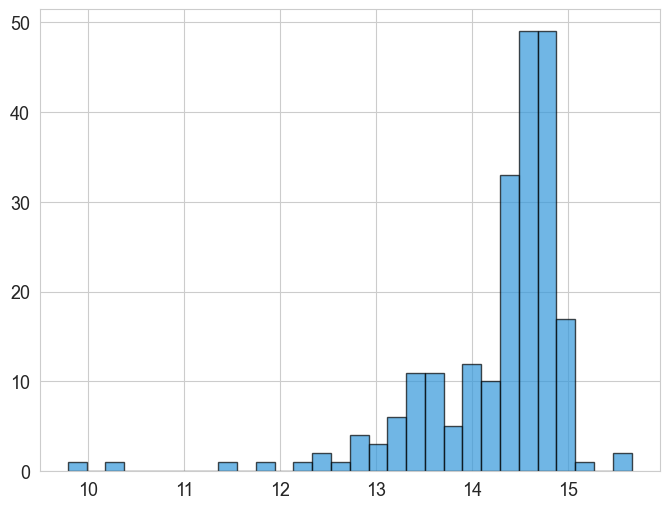

Mean difference (AWW Detection - Arrival Time): 14.3±0.8 days (n=221)

Countries with lowest mean differences (AWW Detection - Arrival Time):
  Gibraltar: Mean Difference = 9.8 days
  Falkland Islands: Mean Difference = 10.3 days
  Barbados: Mean Difference = 11.5 days
  Iceland: Mean Difference = 11.8 days
  Montserrat: Mean Difference = 12.3 days
Countries with continent mapping: 220


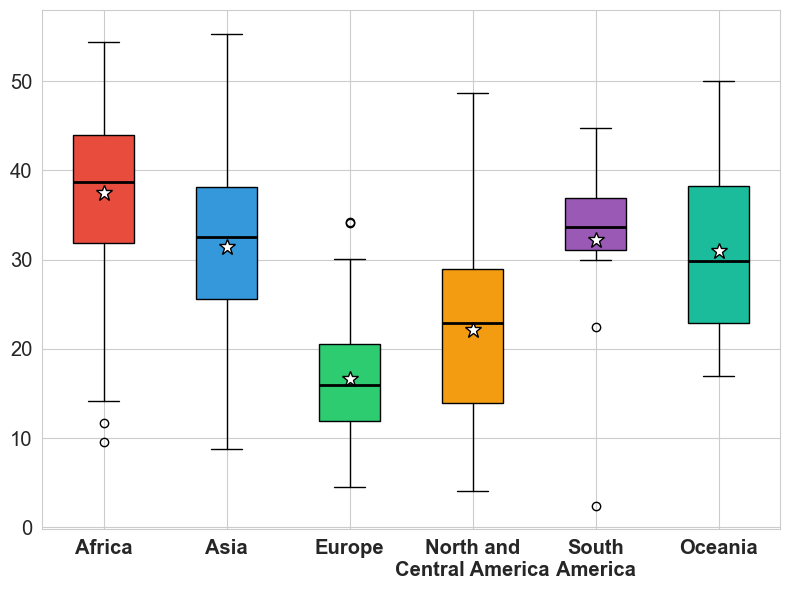

Boxplot complete. Data from 220 countries across 6 continents.

Arrival time statistics by continent:
Africa: 58 countries, mean = 37.5±9.8 days
Asia: 49 countries, mean = 31.4±10.3 days
Europe: 38 countries, mean = 16.7±7.0 days
North and
Central America: 39 countries, mean = 22.2±10.8 days
South
America: 14 countries, mean = 32.1±10.1 days
Oceania: 22 countries, mean = 31.0±9.9 days


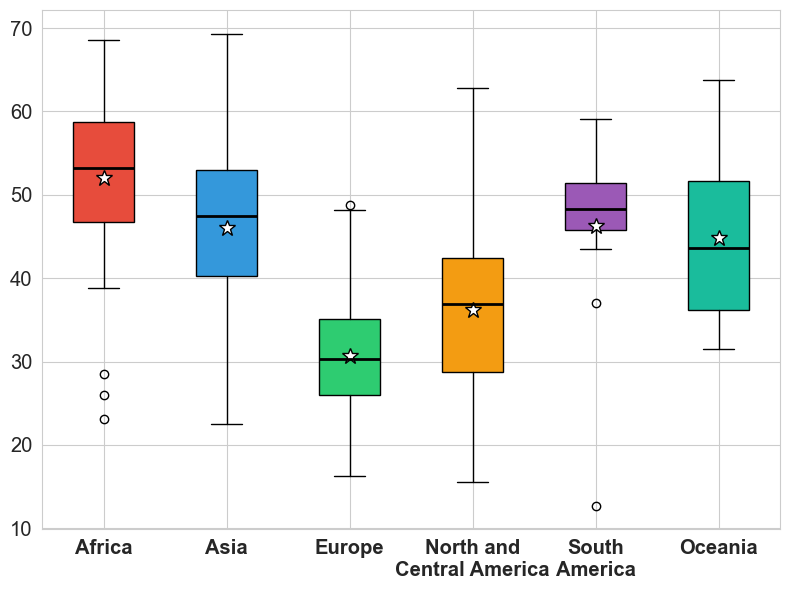

Boxplot complete. Data from 220 countries across 6 continents.

Detection time statistics by continent:


KeyError: 'mean_detetion_time'

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
# Use the arrival_detection_data for the histogram and boxplot
ax.hist(arrival_detection_data['mean_differences'].dropna(), bins=30, color='#3498DB', alpha=0.7, edgecolor='black')
# plt.xlabel('AWW Detection - Arrival Time (Days)')
# plt.ylabel('Number of Countries')
ax.tick_params(labelsize=13)
plt.savefig('/Users/reddy/figures/arrival_time_histogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print mean differences statistics
mean_diff = arrival_detection_data['mean_differences'].dropna()
print(f"Mean difference (AWW Detection - Arrival Time): {mean_diff.mean():.1f}±{mean_diff.std():.1f} days (n={len(mean_diff)})")

# Print lowest 5 mean differences
lowest_diffs = arrival_detection_data.nsmallest(5, 'mean_differences')[['country', 'mean_differences']]
print("\nCountries with lowest mean differences (AWW Detection - Arrival Time):")
for _, row in lowest_diffs.iterrows():
    print(f"  {row['country']}: Mean Difference = {row['mean_differences']:.1f} days")

# Add continent information to arrival_detection_data
final_df = arrival_detection_data.copy()
final_df['continent'] = final_df['country'].map(country_to_region)
final_df = final_df.dropna(subset=['continent'])

print(f"Countries with continent mapping: {len(final_df)}")

fig2, ax2 = plt.subplots(figsize=(8, 6))
# Filter order to only regions present
active_regions = [r for r in region_order if r in final_df['continent'].unique()]
data_to_plot = [final_df[final_df['continent'] == r]['mean_arrival_time'].values for r in active_regions]

bp = ax2.boxplot(data_to_plot, patch_artist=True, medianprops=dict(color='black', linewidth=2))

for i, region in enumerate(active_regions):
    bp['boxes'][i].set_facecolor(continent_colors[region])
    ax2.plot(i + 1, np.mean(data_to_plot[i]), marker='*', color='white', markeredgecolor='black', markersize=12)
ax2.tick_params(labelsize=14.5)
ax2.set_xticklabels(active_regions, fontweight='bold', fontsize=14.5)
# ax2.set_ylabel('Arrival Time (Days)', fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/reddy/figures/arrival_time_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Boxplot complete. Data from {len(final_df)} countries across {len(active_regions)} continents.")

# Print summary statistics by continent
print("\nArrival time statistics by continent:")
for region in active_regions:
    region_data = final_df[final_df['continent'] == region]['mean_arrival_time']
    print(f"{region}: {len(region_data)} countries, mean = {region_data.mean():.1f}±{region_data.std():.1f} days")

fig3, ax3 = plt.subplots(figsize=(8, 6))
# Filter order to only regions present
active_regions = [r for r in region_order if r in final_df['continent'].unique()]
data_to_plot = [final_df[final_df['continent'] == r]['mean_detection_time'].values for r in active_regions]

bp = ax3.boxplot(data_to_plot, patch_artist=True, medianprops=dict(color='black', linewidth=2))

for i, region in enumerate(active_regions):
    bp['boxes'][i].set_facecolor(continent_colors[region])
    ax3.plot(i + 1, np.mean(data_to_plot[i]), marker='*', color='white', markeredgecolor='black', markersize=12)
ax3.tick_params(labelsize=14.5)
ax3.set_xticklabels(active_regions, fontweight='bold', fontsize=14.5)
# ax3.set_ylabel('AWW Detection Time (Days)', fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/reddy/figures/detection_time_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Boxplot complete. Data from {len(final_df)} countries across {len(active_regions)} continents.")

# Print summary statistics by continent
print("\nDetection time statistics by continent:")
for region in active_regions:
    region_data = final_df[final_df['continent'] == region]['mean_detetion_time']
    print(f"{region}: {len(region_data)} countries, mean = {region_data.mean():.1f}±{region_data.std():.1f} days")

Countries with continent mapping and valid data: 221


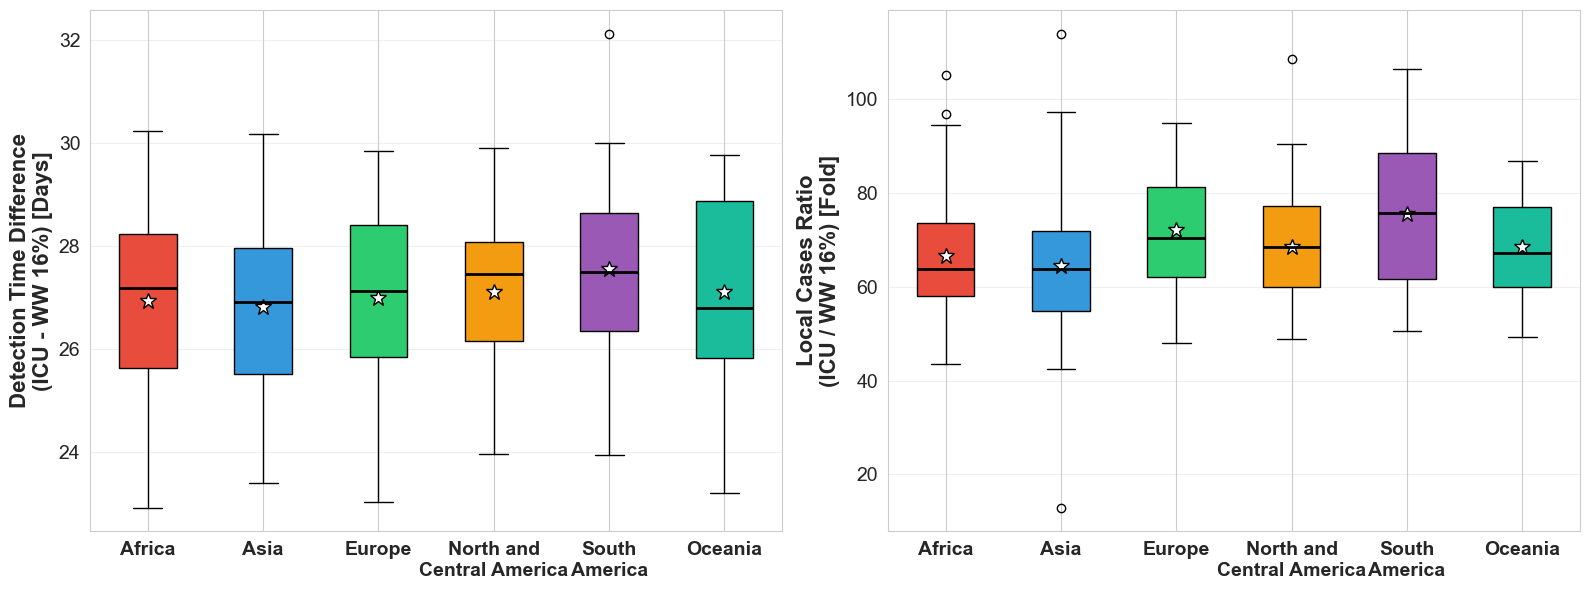

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the full results
results = pd.read_csv("/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/full_results.csv")

# Parse vector columns
import ast
import re

def parse_julia_vector(s):
    if pd.isna(s):
        return []
    s = str(s).strip()
    if re.match(r'^[A-Za-z0-9]+\[\]$', s):
        return []
    try:
        return ast.literal_eval(s)
    except:
        try:
            numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
            return [float(n) for n in numbers]
        except:
            return []

vector_cols = ['ICU_detection_times', 'ICU_local_cases_samples',
               'WW_016_50pct_detection_times', 'WW_016_50pct_local_cases_samples']

for col in vector_cols:
    results[col] = results[col].apply(parse_julia_vector)

# Filter for R0=2, gen_time=4
subset = results[(results['R0'] == 2.0) & (results['gen_time'] == 4.0)].copy()

# Compute differences and ratios for each country
subset['time_diff'] = subset['ICU_mean_detection_time'] - subset['WW_016_50pct_mean_detection_time']
subset['cases_ratio'] = subset['ICU_mean_local_cases'] / subset['WW_016_50pct_mean_local_cases']

# Add continent information
subset['continent'] = subset['country'].map(country_to_region)
subset_with_continent = subset.dropna(subset=['continent', 'time_diff', 'cases_ratio'])

print(f"Countries with continent mapping and valid data: {len(subset_with_continent)}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Detection Time Difference (ICU - WW 16%)
active_regions = [r for r in region_order if r in subset_with_continent['continent'].unique()]
time_diff_data = [subset_with_continent[subset_with_continent['continent'] == r]['time_diff'].values 
                  for r in active_regions]

bp1 = ax1.boxplot(time_diff_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))

for i, region in enumerate(active_regions):
    bp1['boxes'][i].set_facecolor(continent_colors[region])
    ax1.plot(i + 1, np.mean(time_diff_data[i]), marker='*', color='white', 
             markeredgecolor='black', markersize=12)

ax1.set_xticklabels(active_regions, fontweight='bold')
ax1.set_ylabel('Detection Time Difference\n(ICU - WW 16%) [Days]', fontweight='bold')
# ax1.set_title('Detection Time Difference by Continent\n(R0=2, Gen Time=4)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Local Cases Ratio (ICU / WW 16%)
cases_ratio_data = [subset_with_continent[subset_with_continent['continent'] == r]['cases_ratio'].values 
                    for r in active_regions]

bp2 = ax2.boxplot(cases_ratio_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))

for i, region in enumerate(active_regions):
    bp2['boxes'][i].set_facecolor(continent_colors[region])
    ax2.plot(i + 1, np.mean(cases_ratio_data[i]), marker='*', color='white', 
             markeredgecolor='black', markersize=12)

ax2.set_xticklabels(active_regions, fontweight='bold')
ax2.set_ylabel('Local Cases Ratio\n(ICU / WW 16%) [Fold]', fontweight='bold')
# ax2.set_title('Local Cases Ratio by Continent\n(R0=2, Gen Time=4)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()